# **Fitting Fire with Fire (Features): Machine Learning to Parse Human from Natural Causes of Forest Fires**
#### Serenna Walter, Ben Dyer, Manish Reddy Kallu, Bradley Allen

# Background

Oregon is one of the most wildfire prone states in the nation. The fireseason in Oregon typically ranges from May through September. The severity of fire season is due to a number of different factors, including drought, snowpack levels, and weather conditions. In 2024, a record breaking 1.9 million acers were burned due to wildfire in Oregon, including the destruction of homes (Plante, 2024). Naturally caused wildfires (from lightning) tend to occur in the earlier parts of fire season, whereas human-caused wildfires tend to occur later in the season (Western Fire Cheifs Association, 2023). Human caused wildfires tend to be the most destructive (Davis, 2023).


Being able to predict areas most vulnerable to wildfires or when wildfires will occur can be very powerful in the planning and allocation of firefighting resources. Machine learning offers one way that these questions can be examined. By modeling wildfire locations and severity, Oregon can be more prepared to fight and prevent upcoming wildfires.


This project examines the question "In Oregon, how do environmental and human-related factors differently predict human-caused versus lightning-caused wildfires?" The goals for this project are 1) How does this model perform at predicting wildfires generally? 2) How does this model perform at predicting lightning vs. human wildfires?

# Data

Data for this project was acquired from two sources:

1.) U.S. Wildfire Dataset from Kaggle (https://www.kaggle.com/datasets/firecastrl/us-wildfire-dataset/data)

2.) Oregon Department of Forestry Fire Occurrence Data (https://catalog.data.gov/dataset/odf-fire-occurrence-data-2000-2022)

The U.S. Wildfire data set is a national data set that contains geospatial data with multiple predictor variables for detecting fire (e.g., precipitation, present of fuel such as grass) and predicting direction of spread (e.g., wind speed, terrain).  We paired this data with the Oregon Fire data on longitude and langtitude, which allowed us to incorporate human vs. lightning causes of fires.  The U.S. Wildfire data set contained 19 variables and 9,509,925 observations, while the Oregon Fire data set contained 38 variables and 23,490 observations.  For a complete review of the join code and feature selection, see the join code note book.  For a complete review of the selected features, see the feature dictionary.

## Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier, VotingClassifier, GradientBoostingClassifier
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (ConfusionMatrixDisplay, RocCurveDisplay, accuracy_score, classification_report, confusion_matrix, roc_auc_score)
from sklearn.model_selection import GridSearchCV, train_test_split, cross_val_score
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, MinMaxScaler, StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, plot_tree

## Working Directory and File Path

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# The path to your shared drive folder
path = "/content/drive/Shareddrives/DATA505_ML_Group_Project/Jupyter NB/oregon_wildfire_feature_selection.csv"

df = pd.read_csv(path)

## Exploratory Data Analysis

This section includes the EDA of the joined project dataset.



### Overview

Below is an initial overview of the structure and summary statistics of the dataset across all features. A table showing the counts of human-caused wildfires and lightning caused wildfires is also included. There are 865 human caused wildfires in the dataet, 300 lightnign caused, and 1 wildfire that is under investigation.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2915 entries, 0 to 2914
Data columns (total 34 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   serial              1166 non-null   float64
 1   fire_name           1166 non-null   object 
 2   district_name       1166 non-null   object 
 3   unit_name           1166 non-null   object 
 4   fire_category       1166 non-null   object 
 5   human_or_lightning  1166 non-null   object 
 6   specific_cause      1151 non-null   object 
 7   size_class          1166 non-null   object 
 8   est_total_acres     1165 non-null   float64
 9   f_o_land_own_type   1166 non-null   object 
 10  latitude            2915 non-null   float64
 11  longitude           2915 non-null   float64
 12  pr                  2915 non-null   float64
 13  tmmx                2915 non-null   float64
 14  tmmn                2915 non-null   float64
 15  vs                  2915 non-null   float64
 16  vpd   

In [ ]:
df.describe()

,serial,est_total_acres,latitude,longitude,pr,tmmx,tmmn,vs,vpd,bi,...,pet,pr_7d_avg,pr_30d_sum,tmmx_7d_avg,vpd_7d_avg,vs_7d_avg,fire_year,fire_month,fire_day,fire_target
count,1166.000000,1165.000000,2915.000000,2915.000000,2915.000000,2915.000000,2915.000000,2915.000000,2915.000000,2915.000000,...,2915.000000,2915.000000,2915.000000,2915.000000,2915.000000,2915.000000,2915.000000,2915.000000,2915.000000,2915.000000
mean,111021.157804,392.866541,43.787064,-121.479882,1.243739,297.683259,281.451561,3.406998,1.323722,33.810635,...,5.021750,0.887222,27.452144,297.538187,1.307010,3.425779,2017.204460,7.026072,15.797256,0.400000
std,10078.700060,5987.739671,1.276666,1.917454,5.150780,8.160603,5.780973,1.304419,0.769988,20.389982,...,1.884379,2.328475,49.695955,7.303298,0.666212,0.820158,2.434886,1.877148,8.847701,0.489982
min,96186.000000,0.000000,41.994329,-124.429444,0.000000,264.000000,253.500000,0.800000,0.000000,0.000000,...,0.100000,0.000000,0.000000,270.471429,0.000000,0.642857,2014.000000,1.000000,1.000000,0.000000
25%,102371.750000,0.010000,42.499827,-123.023800,0.000000,292.600000,277.700000,2.600000,0.700000,23.000000,...,3.800000,0.000000,3.600000,292.785714,0.772143,2.885714,2015.000000,6.000000,8.000000,0.000000
50%,109247.000000,0.100000,43.768020,-121.804600,0.000000,298.900000,282.200000,3.200000,1.260000,38.000000,...,5.400000,0.085714,14.300000,298.928571,1.261429,3.285714,2017.000000,7.000000,15.000000,0.000000
75%,118127.000000,0.300000,44.791820,-120.652700,0.000000,303.800000,285.500000,4.000000,1.825000,48.500000,...,6.400000,0.857143,31.200000,303.100000,1.798571,3.785714,2019.000000,8.000000,23.000000,1.000000
max,133983.000000,173393.000000,46.296890,-116.454500,134.200000,317.000000,295.700000,18.100000,4.160000,89.000000,...,10.700000,43.742857,726.900000,313.185714,3.527143,10.442857,2022.000000,12.000000,31.000000,1.000000


In [ ]:
# Counts of observations for human and lightning wildfires
df["human_or_lightning"].value_counts()

,count
human_or_lightning,
Human,865
Lightning,300
Under Invest,1


### Oregon Wildfires by Acres Burned Per Year

Below is a bar graph that displays the frequency of human-caused and lightning-caused wildfires within the dataset timespan. Besides lightning caused wildfires slightly showing a decreasing trend, there does not seem to be a clear trend shown across the timespan.

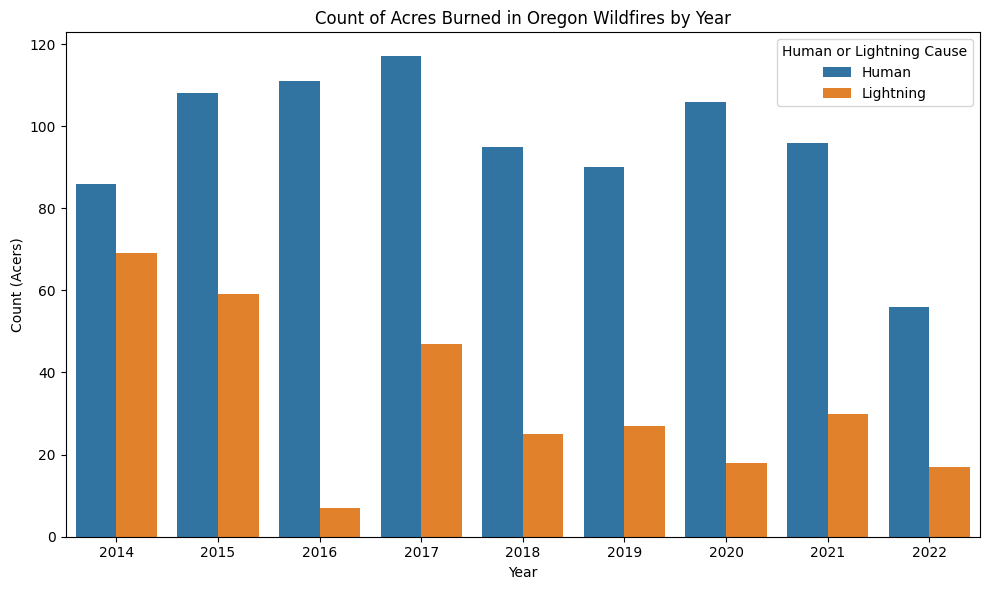

In [ ]:
only_wildfires = df[
    (df['fire_target'] == 1) &
    ((df['human_or_lightning'] == 'Human') | (df['human_or_lightning'] == 'Lightning'))].copy()

acers_year_summary = pd.DataFrame(only_wildfires.groupby(['fire_year', 'human_or_lightning'])['est_total_acres'].count()).reset_index()

acers_year_summary = acers_year_summary.rename(columns = {'est_total_acres': 'count'})

# Making FireYear an integer insead of float bc it has decimal point
acers_year_summary['fire_year'] = acers_year_summary['fire_year'].astype(int)

# Table: Counts by Year
#print(acers_year_summary)

# Bargraph: Counts by Year
fig, ax = plt.subplots(figsize=(10, 6))

plot_data = acers_year_summary.copy() # Making copy of acers_year_summary for the plot because need to have year as string
plot_data = plot_data.sort_values('fire_year')
plot_data['fire_year'] = plot_data['fire_year'].astype(str)

sns.barplot(
    data=plot_data,
    x='fire_year',
    y='count',
    hue='human_or_lightning',
    #orient='h',
    ax=ax
)

ax.set_xlabel("Year")
ax.set_ylabel("Count (Acers)")
ax.set_title("Count of Acres Burned in Oregon Wildfires by Year")
ax.legend(title='Human or Lightning Cause')
plt.tight_layout()
plt.show()

### Top 10 Specific Causes of Human Induced Wildfires

To further examine the specific causes of human-induced wildfires, the table below displays the top 10 most frequent specific ignition causes. Most of these wildfires are miscellaneous related. Burning vehicle or equipment is the second most frequent cause and arson related is the third.

In [ ]:
only_human_wildfires = df[
    (df['fire_target'] == 1) &
    (df['human_or_lightning'] == 'Human')].copy()

human_categories = pd.DataFrame(only_human_wildfires.groupby('specific_cause')['est_total_acres'].count()).reset_index()

human_categories = human_categories.rename(columns = {'est_total_acres': 'count'})

# Table: Top 10 specific causes and thier counts
top10_human_causes = human_categories.sort_values('count', ascending=False).head(10).reset_index(drop=True)

print(top10_human_causes)

                                      specific_cause  count
0                      Other - Miscellaneous Related     72
1                       Burning Vehicle or Equipment     59
2                              Other - Arson Related     53
3                         Carbon Sparks from Vehicle     48
4                                   Burning Building     45
5                        Discarded Cigarette/Tobacco     39
6                          Campfire Not Extinguished     34
7  Other -Equipment Use Related (ie. road const.,...     30
8                            Other - Burning Related     27
9                                  Inadequate Mop Up     24


### Histograms of Variables

Below shows the distribution for each of the numeric variables in the dataset.While most variables are reasonably normally distributed, there is skewness in precipitation measures (e.g., those beginning with pr) and windspeed measures (e.g., those beginning with vs).  We address this in our pre-processing pipeline.

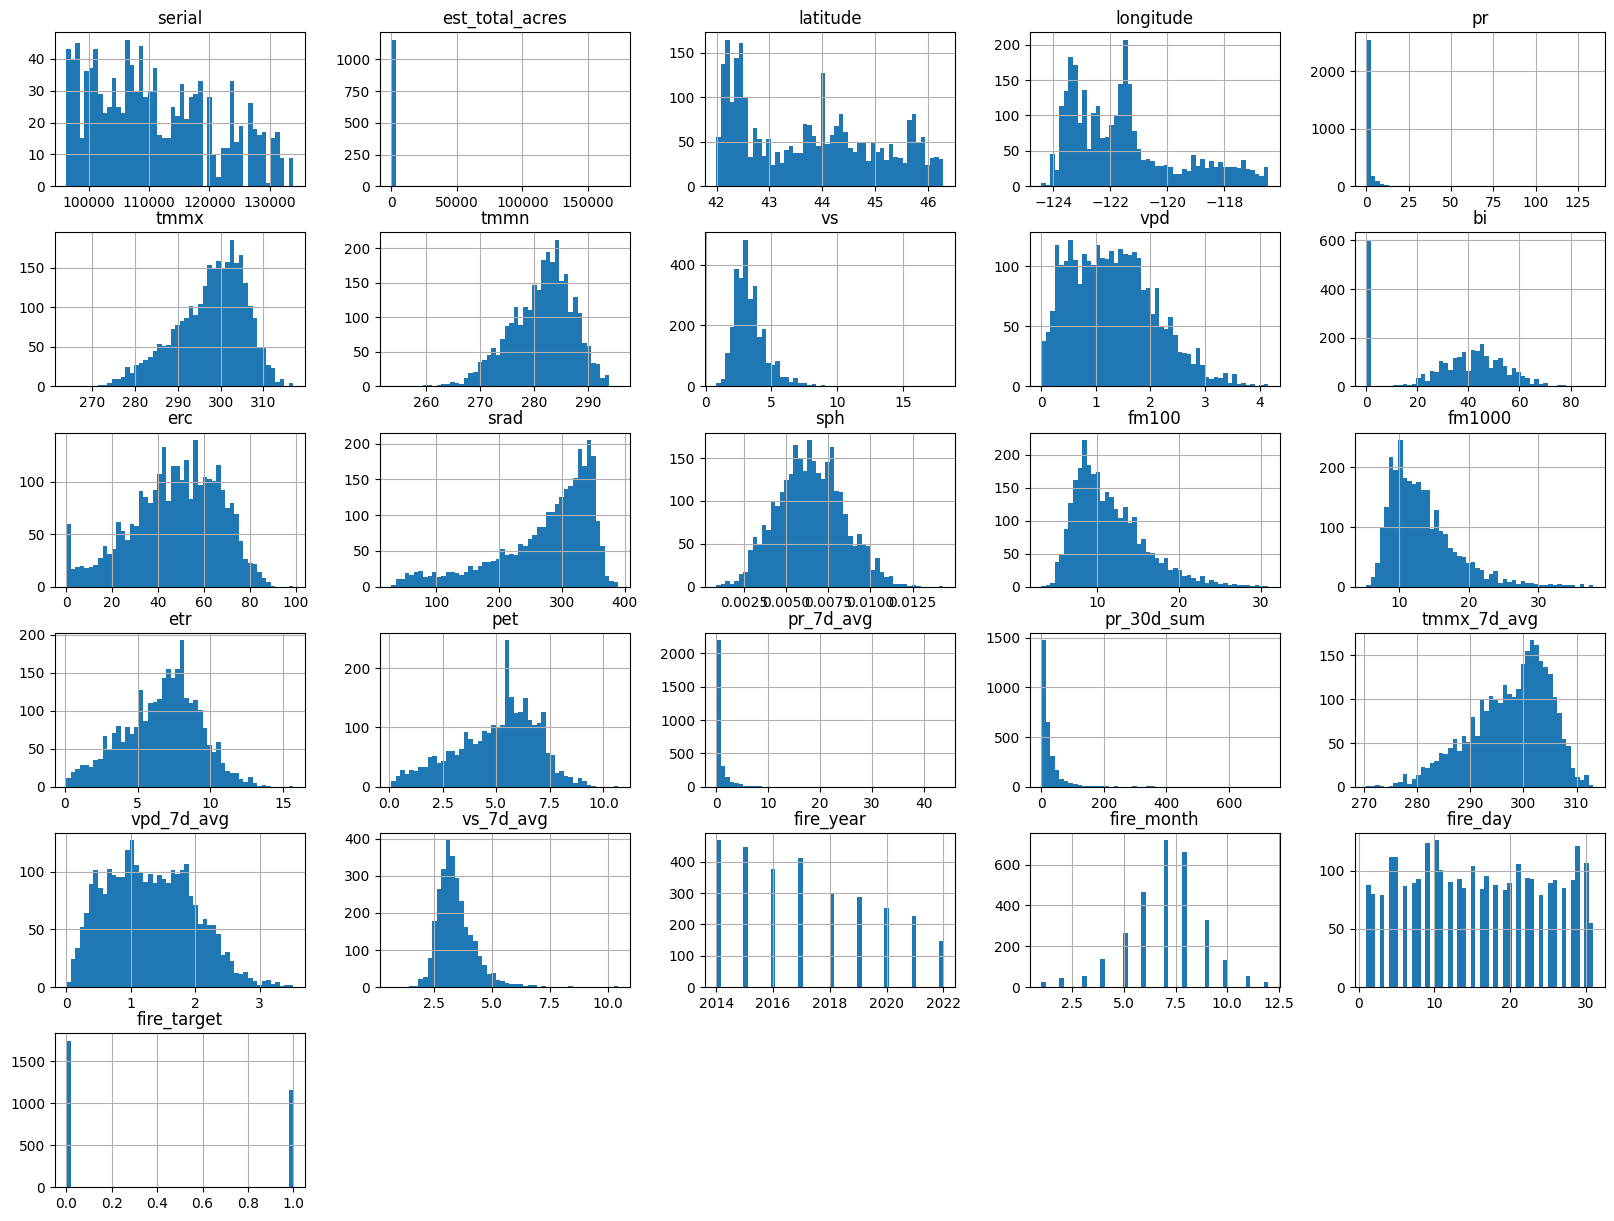

In [ ]:
df.hist(bins=50, figsize=(20,15))
plt.show()

### Correlation Matrix for Numeric Feautres

Below is a correlation heatmap for all numeric varables. Before computing correlations, rows containing missing values were dropped to ensure completeness. Non-predictive variables were also excluded in order to keep the matrix square. Although some of our variables are highly correlated, we chose not to eleminate them as these are the same variables tested on by the researchers who created the U.S. Wildfire data set.  Our goal is to replicate the U.S. Wildfire training as closely as we can, then create novel models to address human vs. lightning caused fires.

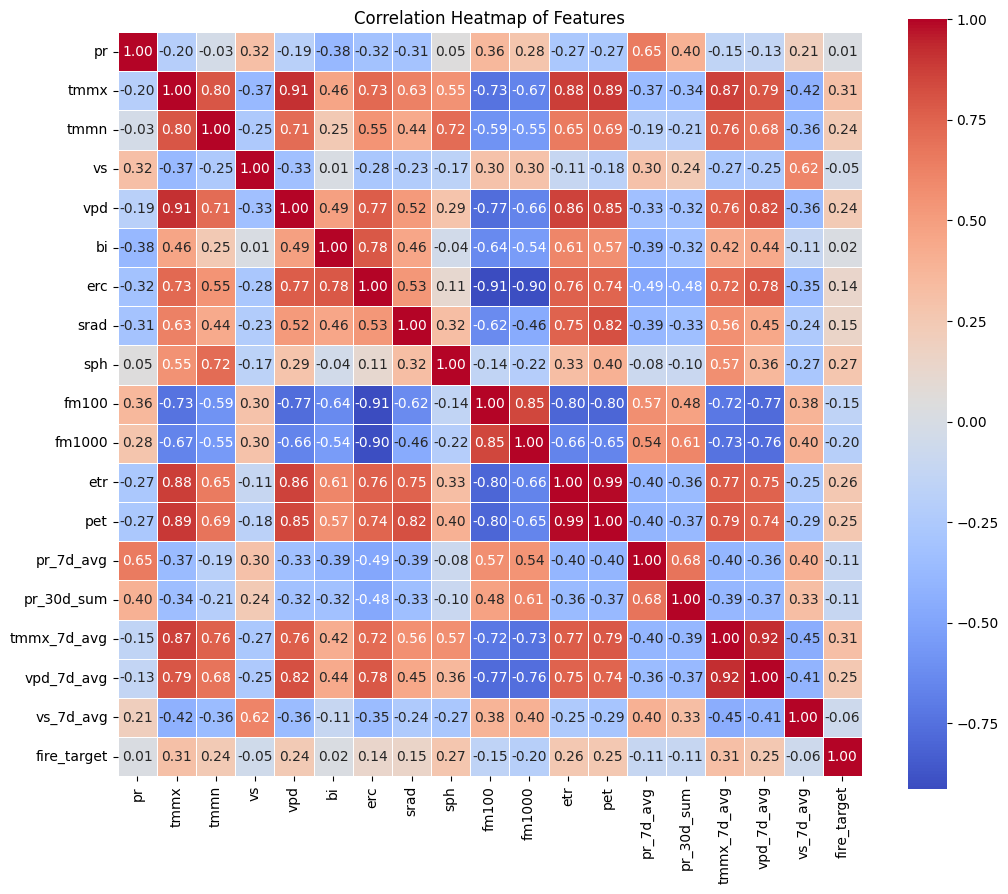

In [ ]:
# 1. Load data set
df_numeric = df.copy()

# 2. Drop columns that contain ANY NaN values
df_numeric = df_numeric.dropna(axis=1, how='any')

# 3. Drop corresponding rows to keep the matrix square
df_numeric = df_numeric.dropna(axis=0, how='any')

df_numeric = df_numeric.drop([
    'latitude',
    'longitude',
    'fire_year',
    'fire_day',
    'fire_month'],
    axis=1,
    errors='ignore')

correlation_matrix = df_numeric.corr()


# 3. Set up the matplotlib figure
plt.figure(figsize=(12, 10))

# 4. Plot the heatmap using seaborn.heatmap()
sns.heatmap(
    correlation_matrix,
    annot=True,     # Display the correlation coefficients on the heatmap
    cmap='coolwarm',# Choose a color map (e.g., 'coolwarm', 'viridis', 'RdBu')
    linewidths=0.5, # Add lines between cells
    square=True,    # Ensure cells are square aspect ratio
    fmt=".2f"       # Format annotations to two decimal places
)

# 5. Add a title to the plot
plt.title('Correlation Heatmap of Features')

# 6. Display the plot
plt.show()

### Check Variance

Variance across all numeric variables were computed. There is a wide range in variability between features. Given the high variance, and different scales of our variables, we apply transformations in our pipeline to keep our variables from biasing our models.

In [ ]:
df_var = df_numeric.var()
df_var

,0
pr,26.530533
tmmx,66.595444
tmmn,33.419643
vs,1.701509
vpd,0.592881
bi,415.751363
erc,378.633304
srad,6078.638128
sph,0.000004
fm100,18.217031


### Pair Plot

This pairplot provides a full glimpse of our features with respect to distribution and correlation. This is a more detailed view of the distribution of variables.

In [ ]:
# This graphic contains too many variables to reliably run in collab, so it has been commented out.
# See histogram of variables for an overview.  Otherwise, uncomment and run if desired.

# sns.pairplot(data = df)

# Method

This project builds directly upon Marthur et al. (2025), who created a spatiotemporal wildfire prediction model to predict wildfires across the United States. Mathur et al. identified that the primary challenge to their model's performance was unpredictible human-caused ignitions independent of weather patterns. The first goal of this project replicates the fire prediction component of the Marthur et al. paper: to predict fires generally. This project builds upon this research by also examing predictors of human-caused wildfires.

Both regression and classification models were made: Logistic Regression, Decision Tree, K-Nearest Neighbors (KNN), Random Forest, and Gradient Boosting. The top three performers were chosen to be included in a hard-voting ensemble model.  Expand this section to review model accuracy reports.

## Model Accuracy Reports

Table 1 summarizes the accuracy reports for our test models.  This was compiled from data produced in the individual model notebooks included in this project file.  Each model employed random_state = 42 to ensure consistency between each project and to facilitate reproducibility.  The models are sorted by recall in descending order.  Recall scores indicate the ability of the model to identify positive instances within the data.  High recall is critical when the cost of missing a positive instance is high.  In the case of this project, predicting no fire occured when a fire actually occured carries significantly higher risk than predicting a fire occured when a fire did not occur.  The reports are ordered by predictor variable (e.g., fire prediction models on the left and human vs. lightning models on the right) and region (e.g., from top to bottom, state, coast, valley, east).  The model with the highest recall score is highlighted in grey.

Table 1: Initial Model Accuracy Reports

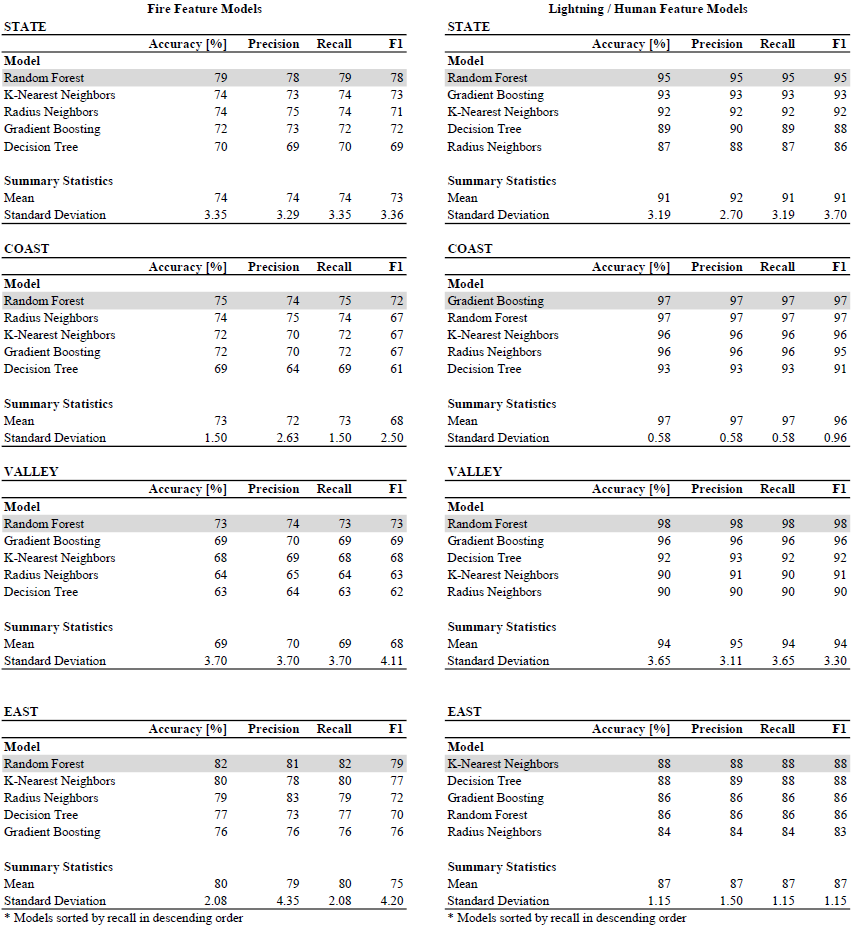

## Preprocessing

This section includes final data cleaning, feature engineering (e.g., extreme weather variables) not addressed in the join code, the creation of feature lists, and details on how the data frames were split by region.  Expand each section for more details on the design decision / rationale for inclusion.

### Clean Data

Here we dropped one row of data for the human vs. lightning data where the cause (e.g., human or lightning) was listed as under investigation.  We also set the human and lightning column head to lower and created mapping that replaced lightning with 0 and human with 1 as binary indicators to facilitate supervised learning.

In [ ]:
# 0. Remove under investigation rows (only 1 row)
df = df[df['human_or_lightning'] != 'Under Invest']

# 1. Clean the text (lowercase and remove spaces)
df['human_or_lightning'] = df['human_or_lightning'].str.strip().str.lower()

# 2. Use a lowercase mapping
mapping = {'lightning': 0, 'human': 1}

# 3. Apply map and fill remaining gaps
df['human_or_lightning'] = df['human_or_lightning'].replace(mapping)

/tmp/ipykernel_926/406196228.py:11: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['human_or_lightning'] = df['human_or_lightning'].replace(mapping)


## Feature Engineering

Cyclic month encoding. fire_month is encoded as sine and cosine values so the model understands that December and January are temporally close rather than opposite ends of a numeric scale.

Temperature and moisture interactions. temp_range captures daily temperature swing as a proxy for fuel dryness. vpd_tmax and vpd_wind are interaction terms that compound vapor pressure deficit with temperature and wind speed.

Dryness index. Combines VPD, 7-day average max temperature, and 30-day cumulative precipitation into a single signal reflecting sustained dryness.

Fuel moisture features. wind_fuel captures how wind interacts with dry fuel loads. fuel_moisture_deficit inverts the 100-hour fuel moisture reading so higher values indicate drier, more combustible fuel.

Extreme fire weather flag (extreme_fire_weather) is a binary indicator set to 1 when maximum temperature exceeds 305K (~90°F), VPD exceeds 2 kPa, and wind speed exceeds 4 m/s simultaneously. It identifies days where multiple high-risk thresholds are crossed at once, which are disproportionately associated with large fire events.

In [ ]:
# Cyclic month encoding
df['month_sin'] = np.sin(2 * np.pi * df['fire_month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['fire_month'] / 12)

# Temperature & moisture interactions
df['temp_range']            = df['tmmx'] - df['tmmn']
df['vpd_tmax']              = df['vpd'] * df['tmmx']
df['vpd_wind']              = df['vpd'] * df['vs']
df['dryness_index']         = df['vpd'] + df['tmmx_7d_avg'] - df['pr_30d_sum']
df['wind_fuel']             = df['vs'] * df['fm100']
df['fuel_moisture_deficit'] = 100 - df['fm100']

# Extreme fire weather flag
df['extreme_fire_weather'] = (
    (df['tmmx'] > 305) &
    (df['vpd']  > 2)   &
    (df['vs']   > 4)
).astype(int)

## Create Feature Lists


These lists were created for ease of use when analyzing different feature sets for our models.  The historical_data list contains engineered features from the join code which can be dropped to reduce multicollinearity.  Similarly, if the historical_data is desired, the related_to_hist variables list that contains the variables upon with the engineered features were calculated may be dropped to reduce multicollinearity.  The non-features list contains a set of variables removed for analysis for two reasons: they were either not included in the original U.S. Wildfire research or served as a direct indicator of a fire (e.g., fire_category, est_total_acres, size_class) that would have led to inflated accuracy and threatened model validity.

In [ ]:
# List of vars to manipulate dfs
historical_data = ['pr_7d_avg', 'pr_30d_sum', 'tmmx_7d_avg', 'vpd_7d_avg', 'vs_7d_avg']
related_to_hist = ['pr', 'tmmx', 'vpd', 'vs']
non_features = ['fire_year', 'fire_day', 'fire_month', 'serial', 'fire_name',
                'district_name', 'unit_name', 'fire_category', 'specific_cause',
                'est_total_acres', 'f_o_land_own_type', 'size_class']
fire_indicator = ['fire_target']
human_lightning = ['human_or_lightning']

## Split Data Frames


Given the climate and terrain differences in Oregon, we split our data into three additional regions: coastal (west of the coastal range), valley (between the coastal and cascade mountain ranges), and east (east of the cascade range).  First, we create a base data frame by dropping all non-feature variables.  We then split the data frames using strict longitude ranges for each zone, holding constant longitude. Effectively, this creates a rectangle around the region of interest.  Given the inflexibility of this approach, it is expected that region data will be captured between regions (e.g., the valley will contain some coastal data and vice versa).  This is something that should be addressed in future iterations.

In [ ]:
# Create Base DF
base_df = df.drop(columns = non_features).copy()
base_df.head()

,human_or_lightning,latitude,longitude,pr,tmmx,tmmn,vs,vpd,bi,erc,...,fire_target,month_sin,month_cos,temp_range,vpd_tmax,vpd_wind,dryness_index,wind_fuel,fuel_moisture_deficit,extreme_fire_weather
0,NaN,43.257198,-121.700500,0.0,290.9,277.2,4.0,0.46,34.0,35.0,...,0,-1.000000,-1.836970e-16,13.7,133.814,1.840,258.160000,70.00,82.5,0
1,NaN,44.232190,-120.652700,0.0,302.9,284.0,2.0,1.85,49.0,73.0,...,0,-0.866025,-5.000000e-01,18.9,560.365,3.700,299.664286,17.00,91.5,0
2,NaN,44.460000,-118.352222,0.0,303.1,287.5,3.4,2.30,70.0,86.0,...,0,-0.866025,-5.000000e-01,15.6,697.130,7.820,301.914286,17.68,94.8,0
3,1.0,42.473500,-122.578700,0.0,306.1,291.1,3.5,2.19,50.0,59.0,...,1,-0.500000,-8.660254e-01,15.0,670.359,7.665,295.390000,29.05,91.7,0
4,NaN,43.794860,-121.464600,0.0,284.6,272.6,5.4,0.46,46.0,45.0,...,0,0.866025,-5.000000e-01,12.0,130.916,2.484,290.560000,60.48,88.8,0


### Fire Features Data Frames

In [ ]:
# Fire Predictor DF
fire_features = base_df.drop(columns = human_lightning).copy()

# Split DFs into regions (coastal, valley, and east)
coastal_ff = fire_features[
    (fire_features['latitude'] >= 41.99) & (fire_features['latitude'] <= 46.30) &
    (fire_features['longitude'] >= -124.71) & (fire_features['longitude'] < -123.1)
].copy()

valley_ff = fire_features[
    (fire_features['latitude'] >= 41.99) & (fire_features['latitude'] <= 46.30) &
    (fire_features['longitude'] >= -123.1) & (fire_features['longitude'] <= -122.3)
].copy()

east_ff = fire_features[
    (fire_features['latitude'] >= 41.99) & (fire_features['latitude'] <= 46.30) &
    (fire_features['longitude'] > -122.3) & (fire_features['longitude'] <= -116.45)
].copy()

In [ ]:
"""
Check number of observations / negative and positive percents
for all fire feature data frames
"""
dataframes = {
    "Total Features": fire_features,
    "Coastal": coastal_ff,
    "Valley": valley_ff,
    "East": east_ff
}

for name, region in dataframes.items():
    total = len(region)
    neg = len(region[region['fire_target'] == 0])
    pos = len(region[region['fire_target'] == 1])

    # Calculate percentages
    neg_pct = (neg / total) * 100 if total > 0 else 0
    pos_pct = (pos / total) * 100 if total > 0 else 0

    print(f"{name}: {total} observations = {neg} negative ({neg_pct:.0f}%), {pos} positive ({pos_pct:.0f}%)")

Total Features: 2914 observations = 1749 negative (60%), 1165 positive (40%)
Coastal: 699 observations = 214 negative (31%), 485 positive (69%)
Valley: 487 observations = 229 negative (47%), 258 positive (53%)
East: 1728 observations = 1306 negative (76%), 422 positive (24%)


### Human or Lightning Data Frames


In [ ]:
# Fire Predictor DF
lightning_features = base_df.dropna().drop(columns=fire_indicator).copy()

# Split DFs into regions (coastal, valley, and east)
coastal_lh = lightning_features[
    (lightning_features['latitude'] >= 41.99) & (lightning_features['latitude'] <= 46.30) &
    (lightning_features['longitude'] >= -124.71) & (lightning_features['longitude'] < -123.1)
].copy()

valley_lh = lightning_features[
    (lightning_features['latitude'] >= 41.99) & (lightning_features['latitude'] <= 46.30) &
    (lightning_features['longitude'] >= -123.1) & (lightning_features['longitude'] <= -122.3)
].copy()

east_lh = lightning_features[
    (lightning_features['latitude'] >= 41.99) & (lightning_features['latitude'] <= 46.30) &
    (lightning_features['longitude'] > -122.3) & (lightning_features['longitude'] <= -116.45)
].copy()

In [ ]:
"""
Check number of observations / negative and positive percents
for all lightning / human data frames
"""
lightning_data = {
    "Lightning Features": lightning_features,
    "Coastal LH": coastal_lh,
    "Valley LH": valley_lh,
    "East LH": east_lh
}

for name, region in lightning_data.items():
    total = len(region)
    neg = len(region[region['human_or_lightning'] == 0])
    pos = len(region[region['human_or_lightning'] == 1])

    neg_pct = (neg / total * 100) if total > 0 else 0
    pos_pct = (pos / total * 100) if total > 0 else 0

    print(f"{name}: {total} obs = {neg} negative ({neg_pct:.0f}%), {pos} positive ({pos_pct:.0f}%)")

Lightning Features: 1165 obs = 300 negative (26%), 865 positive (74%)
Coastal LH: 485 obs = 44 negative (9%), 441 positive (91%)
Valley LH: 258 obs = 91 negative (35%), 167 positive (65%)
East LH: 422 obs = 165 negative (39%), 257 positive (61%)


## Model Configuration

To configure our models, we created an index of outcome variables (e.g., fire and human vs. lightning) based on region (e.g., state, coast, valley, east).  The indices at 0 (fire_features) and 4 (lightning_features) represent state level feature selection.  The subsequent indices account for the regions within the outcome variable where ff accounts for fire features and lh accounts for lightning / human features.  By changing the integer assigned to model_index and running the code chunk, the transformation pipeline will be applied to the respective data frame and split into training and testing sets.  The model will then be trained and tested, returning the accuracy report, confusion matrix, and list of important features.

### Pipeline

For the pipeline design, we chose a one-size-fits-all approach to apply to each model. Features with skewed distributions and high variance were transformed using Scikit-Learn's log1p to better approximate the normal distribution, which is necessary for Naive Bayes.  The MinMaxScaler was applied to features based on indices from 0-100.  Normalizing these to [0,1] preserves their relative scale while keeping them inline with other standardized features.  This is best for decision trees and random forests.  Finally, we applied Scikit Learn's StandardScaler which centers the data at 0 with unit variance, ensuring large-scale features do not drown out smaller features.  This is essential for KNN models which use euclidean distance for classification.  The code below contains three lists such that log_features were transformed using log1p, index features were transofrmed using MinMaxScaler, and other_features were transformed using StandardScaler.

In [ ]:
# Change model index to model of interest
model_index = 3

# Select model of interest
"""
0 = fire_features
1 = coastal_ff
2 = valley_ff
3 = east_ff
4 = lightning_features
5 = coastal_lh
6 = valley_lh
7 = east_lh
"""

# Create list of models to choose from
model_choices = [fire_features, coastal_ff, valley_ff, east_ff,
                 lightning_features, coastal_lh, valley_lh, east_lh
                ]

# Use range(0, 4) to include indices 0, 1, 2, and 3
if model_index in range(0, 4):
    target = 'fire_target'
# Use range(4, 8) to include indices 4, 5, 6, and 7
elif model_index in range(4, 8):
    target = 'human_or_lightning'

model_df = model_choices[model_index]

# Group variables for xfmr
log_features = ['pr', 'pr_7d_avg', 'pr_30d_sum']
index_features = ['bi', 'erc']
other_features = ['tmmx', 'tmmn', 'vs', 'vpd', 'srad', 'sph', 'fm100', 'fm1000', 'etr', 'pet',
                  'tmmx_7d_avg', 'vpd_7d_avg', 'vs_7d_avg', 'latitude', 'longitude', 'month_sin',
                  'month_cos', 'temp_range', 'vpd_tmax', 'vpd_wind',
                  'dryness_index', 'wind_fuel', 'fuel_moisture_deficit', 'extreme_fire_weather']

preprocessor = ColumnTransformer(transformers=[
    ('log', FunctionTransformer(np.log1p, feature_names_out='one-to-one'), log_features),
    ('minmax', MinMaxScaler(), index_features),
    ('std', StandardScaler(), other_features)
])

X = model_df.drop(target, axis=1)
y = model_df[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Models to test (EXAMPLE)
models = {
    'KNN (K=23)': KNeighborsClassifier(n_neighbors=23),
    'Naive Bayes': GaussianNB(),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Logistic Reg': LogisticRegression(max_iter=1000, random_state=42),
    'Bagging (DT)': BaggingClassifier(DecisionTreeClassifier(), random_state=42)
}

# Ensemble Models
ensemble_members = [
    ('lr', LogisticRegression(max_iter=1000, random_state=42)),
    ('rf', RandomForestClassifier(random_state=42)),
    ('svm', SVC(random_state=42))
]
models['Ensemble Voting (Hard)'] = VotingClassifier(estimators=ensemble_members, voting='hard')

# Ensemble Model

Instead of recreating state vs. regional models for ensemble, we will focus only on the state.  We believe this is appropriate because our accuracy summaries show state models perform about as well as the regional models.  Furthermore, it is likely that increased recall from regional models is due to overfitting from class imbalance.  This is evident in the significant increase in recall in the lightning / human models (avg. recall ~ 90s) when compared to the fire only models (avg. recall ~ 70s). Therefore, a single ensemble model that uses the top three, non-redundant models (e.g., one KNN, one forest, and gradient boosting) will be both robust enough to make state level predictions and sufficiently conservative to address inflated recall scores from overfitting.

## Planned Analysis

We have created three data frames to predict fires for the most current year (i.e., 2022) using previous years (i.e., 2014-2021).  We will compare the accuracy reports and the important features between fire and human / lightning.  Next, we predict the two largest fires (i.e., Holiday Farm and Chaos Rough-Patch) using previous years up to 30 days prior (i.e., 2014 through July of 2021 for Holiday Farm, and 2014 through June of 2021 for Chaos Rough-Patch).  Finally, the Holiday Farm fire was caused by lightning while the Chaos Rough-Patch fire was human caused.  Therefore, we will use these fires to test the lightning vs. human model.

## Design Choices

Similar to previous models, we used GridSearch to find the best model parameters in a given set (e.g., KNN were k was in 5, 11, 15, 23, 31).  Model scoring was set to recall to minimize the presence of false negatives in the model predictions.  We also applied weights to address class imbalance for the lightning / human data set, which contained 1165 observations where 300 (26%) were negative (i.e., human), 865 (74%) positive (i.e., lightning).  Weighting ensured the human classification was equally considered in the model.  Finally, we set the voting method to hard voting to ensure the most conservative approach to classification (e.g., favoring model agreement over a probability greater than 50%).  On balance, this approach was more dynamic than our original models, but also more conservative as it employed recall and hard voting to reduce false negatives.

## Data Frames

To answer our research question, we split the data into three data frames.  The first is uses our historical data (i.e., 2014 to 2021) to predict the most recent year (i.e., 2022).  We also included two data frames for the largest fires in the data set to test specific cases.  The details for these fires is shown below.  Given that one fire was caused by lightning (Holiday) and the other by human activity (Chaos Rough-Patch), we were able to test all three for the fire target and human or lightning target.

In [ ]:
# Most recent year base frames
mry_train = df[df["fire_year"] != 2022].copy()
mry_test = df[df["fire_year"] == 2022].copy()

In [ ]:
# Largest Fires in 2020 and 2021
df[ (df["fire_name"] == "Holiday Farm") |
    (df["fire_name"] == "Chaos-Rough Patch CMPLX")][
        ["fire_name", "est_total_acres", "fire_year", "fire_month", "fire_day", "human_or_lightning"]]

,fire_name,est_total_acres,fire_year,fire_month,fire_day,human_or_lightning
229,Chaos-Rough Patch CMPLX,50409.0,2021,7,27,0.0
2241,Holiday Farm,173393.0,2020,9,7,1.0


In [ ]:
# Holiday Farm (lightning caused)
holiday_train = df[
    (df["fire_year"] < 2020) |
    ((df["fire_year"] == 2020) & (df["fire_month"] <= 7))
].copy()

holiday_test = df[df["fire_name"] == "Holiday Farm"].copy()

In [ ]:
# Chaos Rough-Patch (human caused)
chaos_train = df[
    (df["fire_year"] < 2021) |
    ((df["fire_year"] == 2021) & (df["fire_month"] <= 6))
].copy()

chaos_train = chaos_train.drop(columns = non_features).copy()

chaos_test = df[df["fire_name"] == "Chaos-Rough Patch CMPLX"].copy()

## Ensemble Code

The ensemble model code can be found in the iPython noebook titled "06_Ensemble_Model" included in the ZIP file.

# Results

Expand for full results. With respect to our initial question (i.e., which features differently predict fires), our model shows that fires are generally predicted by weather features first (e.g., wind, precipitation), and location features second.  By contrast, lightning vs. human fires are better predicted by location and then by weather features (e.g., wind, temperature).

### Model Performance

Overall, the ensemble model under performed when compared to our initial models, but out performed the target model with respect to recall (Table 2).  Fig. 1 contains the confusion matrix and important features for the fire target by state for both the weighted and unweighted models.  Fig. 2 contains the confusion matrix and important features for the lightning vs. human caused fires (weighted and unweighted).  There is a clear delimitation in important features, such that fire risk is generally predicted by weather features like sustained winds over 7 days(vs_7d_avg), sustained dryness over y days (vpd_7d_avg), and precipitation over 7 days (pr_7d_avg).  Conversely, the most important features for predicting lightning vs. human causes are geographical (e.g., latitude, longitiude), followed by weather features (e.g., wind, air temperature, and vapor pressure or dryness of the air).

It is worth noting that our initial models were tuned for best parameters but did not contain penalties like weighting to address class imbalance, recall scoring to reduce false negatives, or hard voting to establish a threshold for classification accuracy. If similar controls were added to our prior models, the ensemble model standing would likely improve.  Importantly, the ensemble model performed about as well as the target, which increases its validity and allows us to extend the research to lightning vs. human classification with relatively high confidence.

In addition to checking model performance by predicting "next year" fires, we also checked against single cases.  Our model accurately predicted the Holiday Farm fire, a naturally caused fire, using data from 2014 up to 30 days before the fire was reported (Table 3). By contrast, our model failed to predict the Chaos Rough-Patch fire, a human caused fire, using data from 2014 to 30 days before the fire was reported (Table 3). For context, the Holiday Farm fire burned an estimated 173,393 acres, while the Chaos Rough-Patch fire burned an estimated 50,409 acres.  Finally, using the same two fires, the ensemble method accurately predicted human vs. lightning causes for both (Table 4).

### Table 2: Model Comparisons

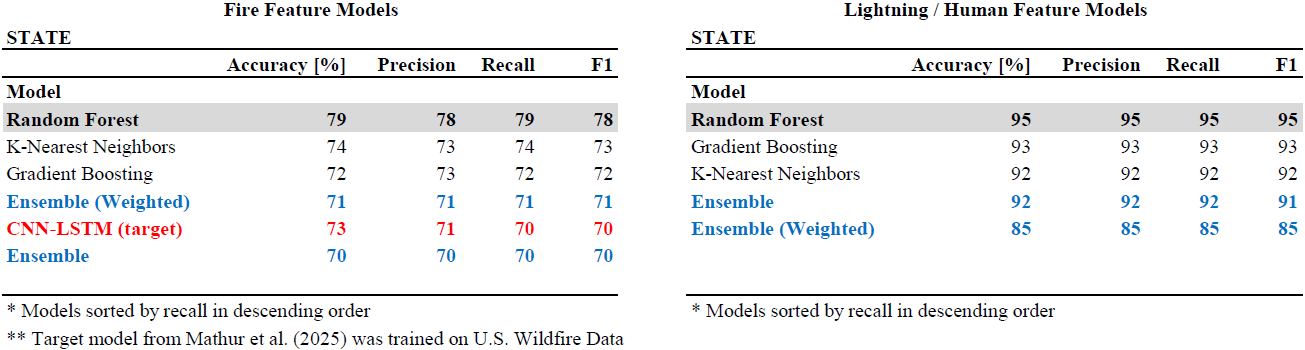

Mathur et al. (2025) paper: https://arxiv.org/pdf/2601.14238

### Fig. 1: Fire Detection Confusion Matrix and Top Features Plot

#### WEIGHTED

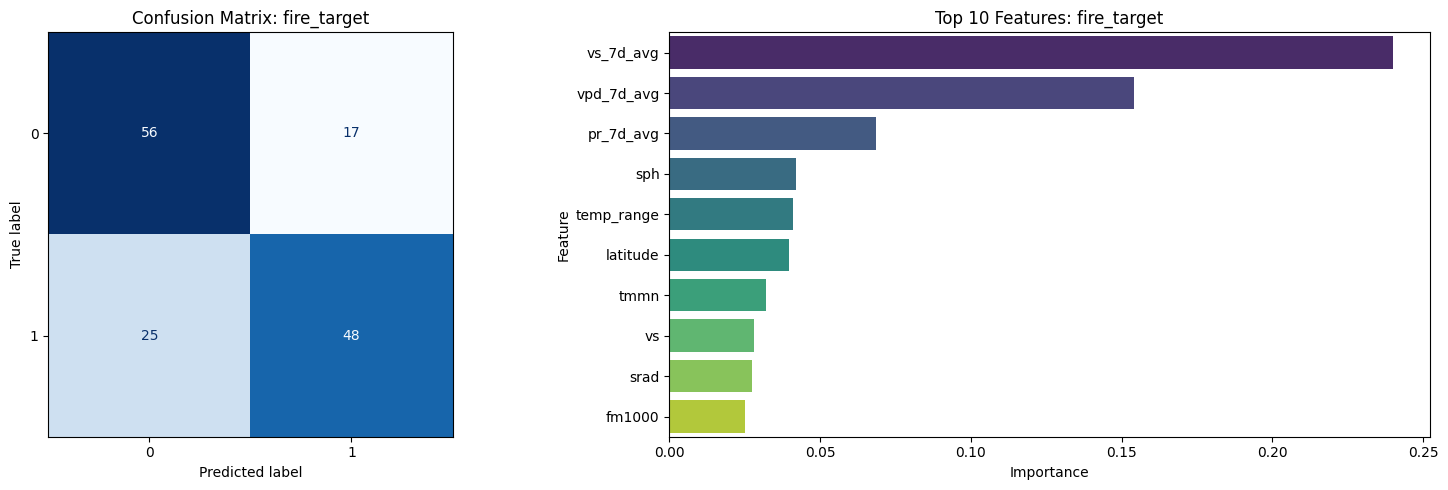

#### UNWEIGHTED

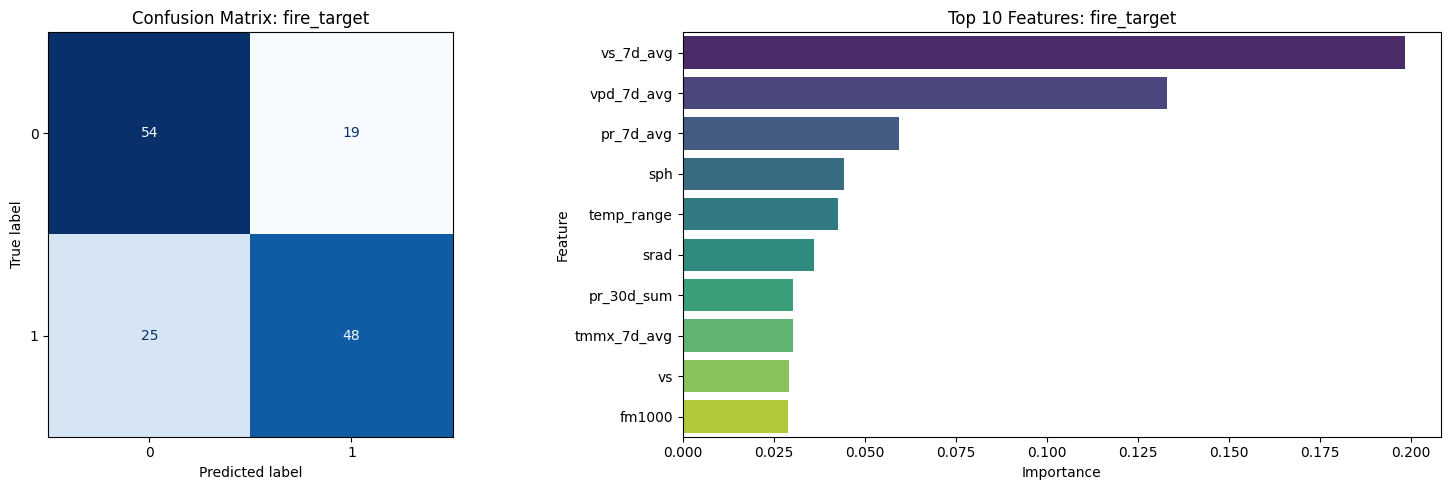

### Fig. 2: Lightning vs. Human Caused Fires Confusion Matrix and Top Features Plot

#### WEIGHTED

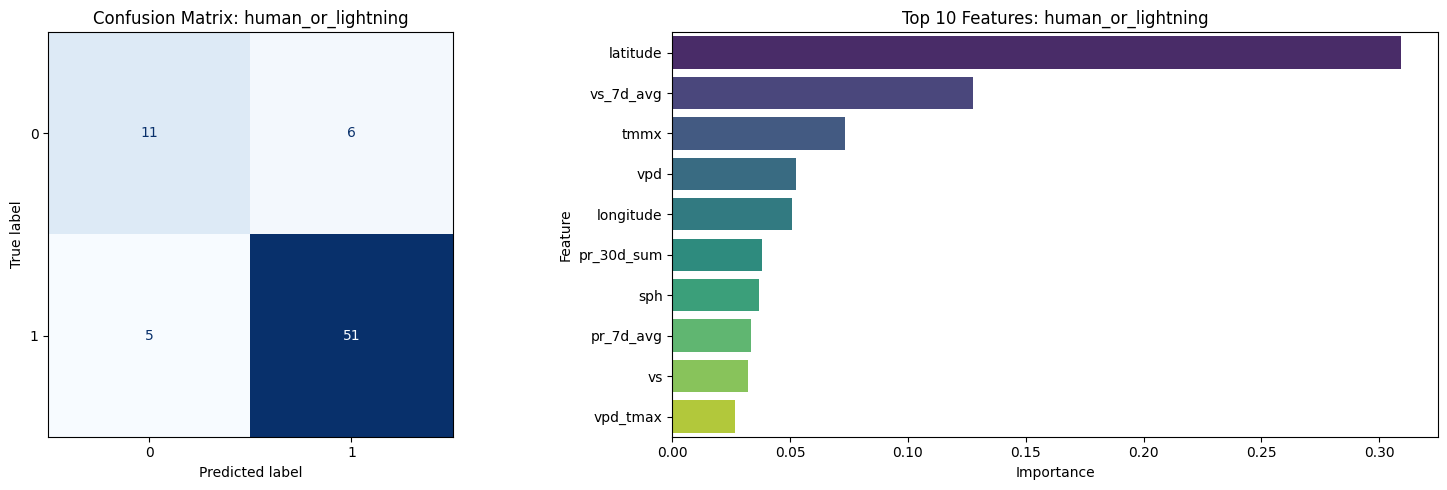

#### UNWEIGHTED

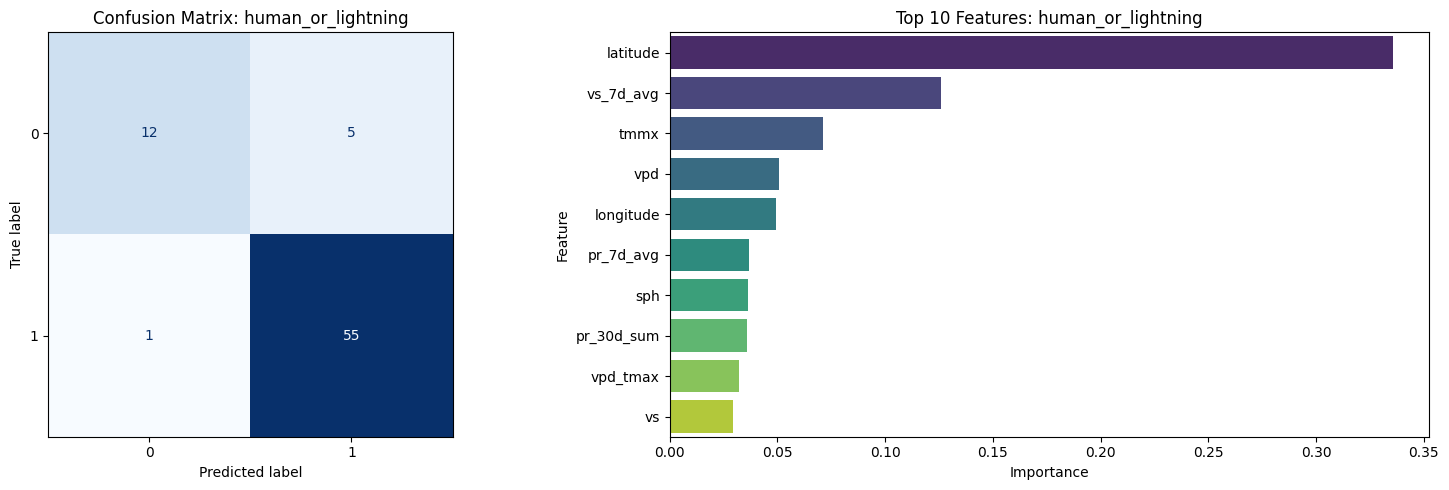

### Single Fire Detection

### Table 3: Single Target Fire Detection

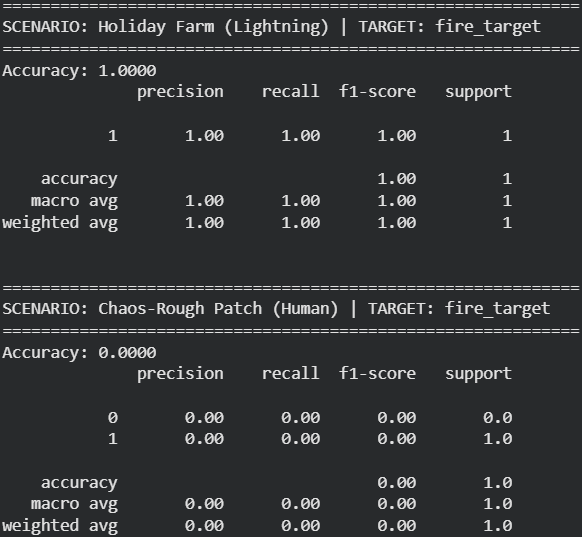

### Table 4: Single Target Lightning vs. Human Detection

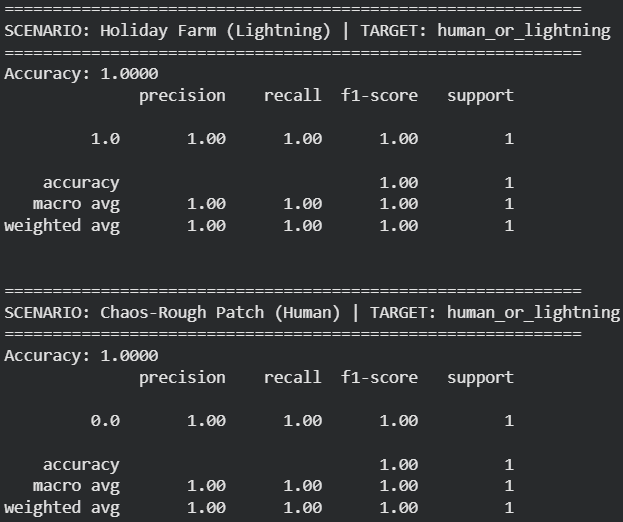

# Conclusion

Our wildfire occurrence model performed comparably to the target model, supporting the effectiveness of environmental predictors for wildfire prediction. Key predictors included wind speed, vapor pressure deficit, and precipitation, which showed strong relationships with wildfire occurrence and suggest that wildfire risk is strongly associated with weather and fuel-related conditions.

Extending the model to classify ignition source also provided important insights. Our results suggested that lightning-caused wildfires were more predictable using environmental variables, which is consistent with the fact that lightning ignitions are more closely tied to measurable environmental conditions. In contrast, human-caused wildfires were more difficult to predict, likely because they may involve factors that are not readily measurable or not captured in our dataset, such as powerline failures, accidental ignitions, infrastructure-related risks, or other human activities. This does not suggest human-caused fires are impossible to predict, but rather that they may require predictors beyond environmental variables alone.

Another important finding from our project is that key predictors may differ between ignition sources, suggesting that wildfire ignition is not driven by a single set of factors. This supports the idea that human-caused and lightning-caused wildfires may need to be treated as distinct prediction problems.

Overall, our results suggest that environmental predictors are effective for wildfire occurrence prediction, but that different ignition sources may require different modeling approaches. More broadly, these findings suggest that human-caused and lightning-caused wildfires may also require different prevention and management strategies.

# Limitations

The original U.S. Wildfire data was created using 3D geometries and expanded historical data.  To combine the data, we had to "flatten" the original geometries to work with the 2D format provided in the Oregon Fire data set.  Although the join code indicates a high level of accuracy, it is possible that not every data point was completely accurate.  Additionally, to prevent class inbalance, we sampled from the negative fire instances from the U.S. Wildfire data, which contained over 9 million rows.  Given the original intent of the U.S. Wildfire to contain a time component in addition to geographical data, sampling like this eliminates the time series component.  While we used engineered features to retain the time series elements (e.g., 7d averages and 30 day sums), our data lacks a continuous flow of time series data compared to the original U.S. Wildfire data set, which means our models are not able to achieve analogous results.

To enable a complete join, we had to restrict the date range of our data.  The U.S. Wildfire file included data from 2014 to 2025, while the Oregon Fire file included data from 2000 to 2022. Given these ranges, our final data frame includes data from 2014 (U.S. Wildfire min year) to 2022 (OR Fire max year). Although we have more than 2914 observations for 9 years, more data would improve model performance

With respect to the individual model files, we encountered some class imbalance issues.  For example, the lightning / human data frame for the coastal region contained 44 negative fire instances (9%) and 441 positive fire instances (91%). This would explain the elevated accuracy results throughout the lightning / human models for the coast, valley, and East.  We address this in the ensemble model by training and testing for data at the state level, which preserves class balance as much as possible.  Nevertheless, the lightning / human data frame contains 300 negative (human) instances (26%) and 865 positive (lightning) instances (74%).

Another area that should be addressed in future work is the pipeline.  We opted for a one-size-fits-all approach to reduce processing time.  This was necessary owing to project time-line constraints.  In the future, we recommend creating pipelines for individual models (e.g., centering for KNN, normalizing for forests). By creating individual pipelines, model performance will likely increase.

Finally, our models may be too conservative.  Model performance could be increase by switching to soft voting which considers probability over model agreement, creating a lower threshold for classification (e.g., greater than 50% vs. 2/3 model agreement).  Additionally, because we use weighting to address class imbalance, it may be redundant to emphasize recall in the scoring method when hard voting is used, instead switching to score = f1 for a better balance between precision and recall.  In our initial tests, score = roc_auc increased precision across all ensemble results (e.g., accuracy, precision, recall, F1).  

# Future Directions

Several directions could extend this project. Adding acreage burned as a secondary outcome would increase practical value — distinguishing a small contained fire from a large-scale event has significant implications for resource allocation, and a regression model trained on est_total_acres alongside the existing pipeline could support that.

Land use type and specific cause were excluded from the current models but likely carry meaningful predictive power. Land use type reflects different ignition risk profiles across federal, private, and agricultural land. Specific cause contains granular human ignition pathways — vehicle sparks, arson, discarded cigarettes, campfires — that could support a more detailed multi-class cause classification model, which would be more actionable for prevention and policy than the current human vs. lightning binary.

Finally, consistent with Mathur et al. (2025), future work could explore Transformer-based architectures better suited to the temporal structure of fire weather data, extend the model to a multi-agent suppression framework, and incorporate real-time weather feeds to support operational forecasting.

# Sources

Davis, Erin & Harris, Emily. July 21, 2023. "People cause about half of Oregon wildfires." Axious Portland. https://www.axios.com/local/portland/2023/07/21/people-cause-half-of-wildfires-in-oregon.


Western Fire Cheifs Association. Feb 22, 2023. "Oregon Fire Season: In-Depth Guide". https://wfca.com/wildfire-articles/oregon-fire-season/.


Plante, Aimee. Oct 28, 2024. "Oregon’s record-breaking wildfire season ends with more than 1.9 million acres burned". https://www.koin.com/news/wildfires/oregon-2024-fire-season-over-10282024/#:~:text=This%20season%2C%20which%20took%20off,strained%20resources%20and%20exhausted%20firefighters.

Mathur et al. 2025. "Spatiotemporal Wildfire Prediction and
Reinforcement Learning for Helitack Suppression". IEEE. https://arxiv.org/pdf/2601.14238.



